# IEEE-CIS Fraud Detection: Modeling

**Goal:** Train and tune fraud detection models

**Approach:**
- Logistic Regression baseline (simple linear model)
- LightGBM (handles missing values, categoricals, imbalance)
- Time-based CV split (no data leakage)
- AUC-ROC as primary metric

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

## 1. Load Processed Data

In [2]:
# Load processed data - separate datasets for different model types
# Tree pipeline: label-encoded categoricals (for LightGBM)
X_train_tree = pd.read_parquet(PROCESSED_DIR / 'X_train_tree.parquet')
X_test_tree = pd.read_parquet(PROCESSED_DIR / 'X_test_tree.parquet')

# Linear pipeline: one-hot encoded categoricals (for Logistic Regression)
X_train_linear = pd.read_parquet(PROCESSED_DIR / 'X_train_linear.parquet')
X_test_linear = pd.read_parquet(PROCESSED_DIR / 'X_test_linear.parquet')

# Shared data
y_train = pd.read_parquet(PROCESSED_DIR / 'y_train.parquet')['isFraud']
test_ids = pd.read_parquet(PROCESSED_DIR / 'test_ids.parquet')['TransactionID']

print(f"Tree pipeline (LightGBM):     {X_train_tree.shape[1]} features")
print(f"Linear pipeline (LogReg):     {X_train_linear.shape[1]} features")
print(f"Training samples:             {len(y_train)}")
print(f"Fraud rate:                   {y_train.mean():.2%}")

Tree pipeline (LightGBM):     454 features
Linear pipeline (LogReg):     519 features
Training samples:             590540
Fraud rate:                   3.50%


## 2. Time-Based Cross-Validation

**Why time-based CV instead of standard k-fold?**

1. **Prevents data leakage**: Standard k-fold randomly mixes transactions, letting the model "peek" at future patterns. In production, we can only use past data to predict future fraud.

2. **Fraud evolves**: Fraudsters constantly adapt tactics. Time-based CV tests whether the model generalizes to *new* fraud patterns it hasn't seen.

3. **Realistic performance estimates**: Random CV inflates AUC scores. Time-based CV gives honest estimates that reflect real-world deployment.

4. **Concept drift detection**: By validating on progressively newer data, we can spot if model performance degrades over time.

The data is already sorted by `TransactionDT`, so `TimeSeriesSplit` trains on earlier transactions and validates on later ones—exactly like production.

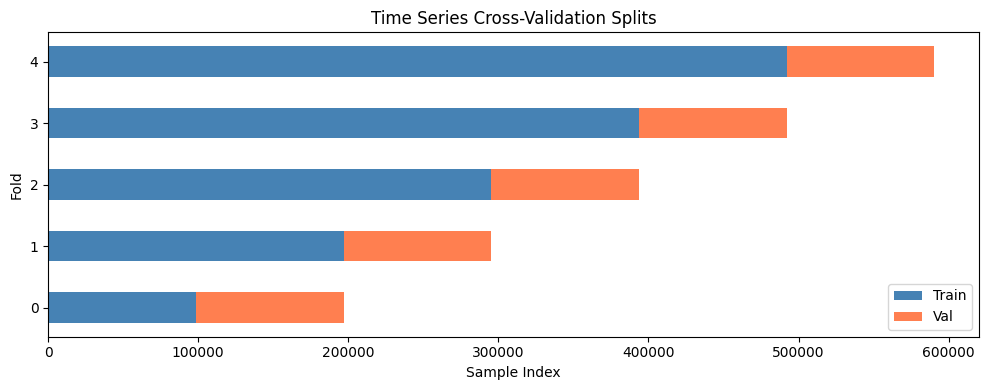

In [3]:
from sklearn.model_selection import TimeSeriesSplit

# Time-based split (data is already sorted by TransactionDT)
tscv = TimeSeriesSplit(n_splits=5)

# Visualize splits (using tree data, but splits are the same)
fig, ax = plt.subplots(figsize=(10, 4))
for i, (train_idx, val_idx) in enumerate(tscv.split(X_train_tree)):
    ax.barh(i, len(train_idx), left=0, height=0.5, label='Train' if i == 0 else None, color='steelblue')
    ax.barh(i, len(val_idx), left=len(train_idx), height=0.5, label='Val' if i == 0 else None, color='coral')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Fold')
ax.set_title('Time Series Cross-Validation Splits')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Baseline: Logistic Regression

Simple linear baseline to compare against more complex models.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Logistic regression needs: imputation + scaling
# Uses ONE-HOT encoded data (X_train_linear) for proper categorical handling
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

# Cross-validation using LINEAR pipeline data
lr_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_linear)):
    X_tr, X_val = X_train_linear.iloc[train_idx], X_train_linear.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    lr_pipeline.fit(X_tr, y_tr)
    val_pred = lr_pipeline.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, val_pred)
    lr_cv_scores.append(score)
    
    print(f"Fold {fold + 1}: AUC = {score:.4f}")

print(f"\nLogistic Regression CV Mean AUC: {np.mean(lr_cv_scores):.4f} (+/- {np.std(lr_cv_scores):.4f})")
print(f"(Using one-hot encoded features: {X_train_linear.shape[1]} features)")

Fold 1: AUC = 0.8290
Fold 2: AUC = 0.8389
Fold 3: AUC = 0.8375
Fold 4: AUC = 0.8639
Fold 5: AUC = 0.8403

Logistic Regression CV Mean AUC: 0.8419 (+/- 0.0117)
(Using one-hot encoded features: 519 features)


## 4. LightGBM Model

In [5]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

# Calculate scale_pos_weight for imbalanced classes
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Baseline parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
}

scale_pos_weight: 27.58


In [6]:
# Cross-validation using TREE pipeline data (label-encoded)
cv_scores = []
models = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tree)):
    X_tr, X_val = X_train_tree.iloc[train_idx], X_train_tree.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )
    
    val_pred = model.predict(X_val)
    score = roc_auc_score(y_val, val_pred)
    cv_scores.append(score)
    models.append(model)
    
    print(f"Fold {fold + 1}: AUC = {score:.4f}")

print(f"\nLightGBM CV Mean AUC: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
print(f"(Using label-encoded features: {X_train_tree.shape[1]} features)")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.889409
[200]	valid_0's auc: 0.889709
Early stopping, best iteration is:
[150]	valid_0's auc: 0.890876
Fold 1: AUC = 0.8909
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.893628
[200]	valid_0's auc: 0.900011
[300]	valid_0's auc: 0.902266
[400]	valid_0's auc: 0.904417
Early stopping, best iteration is:
[401]	valid_0's auc: 0.904493
Fold 2: AUC = 0.9045
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.893426
[200]	valid_0's auc: 0.899121
[300]	valid_0's auc: 0.899819
[400]	valid_0's auc: 0.899966
Early stopping, best iteration is:
[364]	valid_0's auc: 0.900645
Fold 3: AUC = 0.9006
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.908301
[200]	valid_0's auc: 0.916198
[300]	valid_0's auc: 0.917999
[400]	valid_0's auc: 0.918552
Early stopping, best iteration is:
[409]	valid_0's auc: 0.918722
Fold 4: AUC =

MODEL COMPARISON

Logistic Regression: 0.8419 (+/- 0.0117)
LightGBM:            0.9073 (+/- 0.0115)

LightGBM improvement: +0.0654 AUC


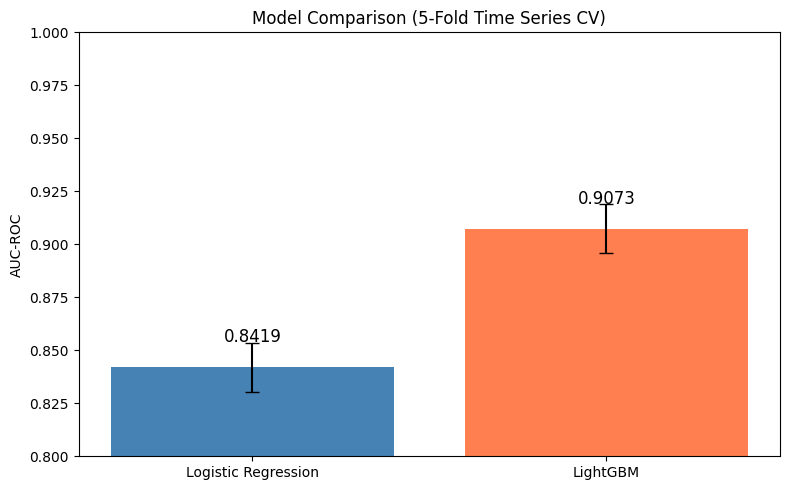

In [7]:
# Model Comparison
print("================")
print("MODEL COMPARISON")
print("================")
print(f"\nLogistic Regression: {np.mean(lr_cv_scores):.4f} (+/- {np.std(lr_cv_scores):.4f})")
print(f"LightGBM:            {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
print(f"\nLightGBM improvement: +{(np.mean(cv_scores) - np.mean(lr_cv_scores)):.4f} AUC")

# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 5))
models_names = ['Logistic Regression', 'LightGBM']
means = [np.mean(lr_cv_scores), np.mean(cv_scores)]
stds = [np.std(lr_cv_scores), np.std(cv_scores)]

bars = ax.bar(models_names, means, yerr=stds, capsize=5, color=['steelblue', 'coral'])
ax.set_ylabel('AUC-ROC')
ax.set_title('Model Comparison (5-Fold Time Series CV)')
ax.set_ylim(0.8, 1.0)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{mean:.4f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

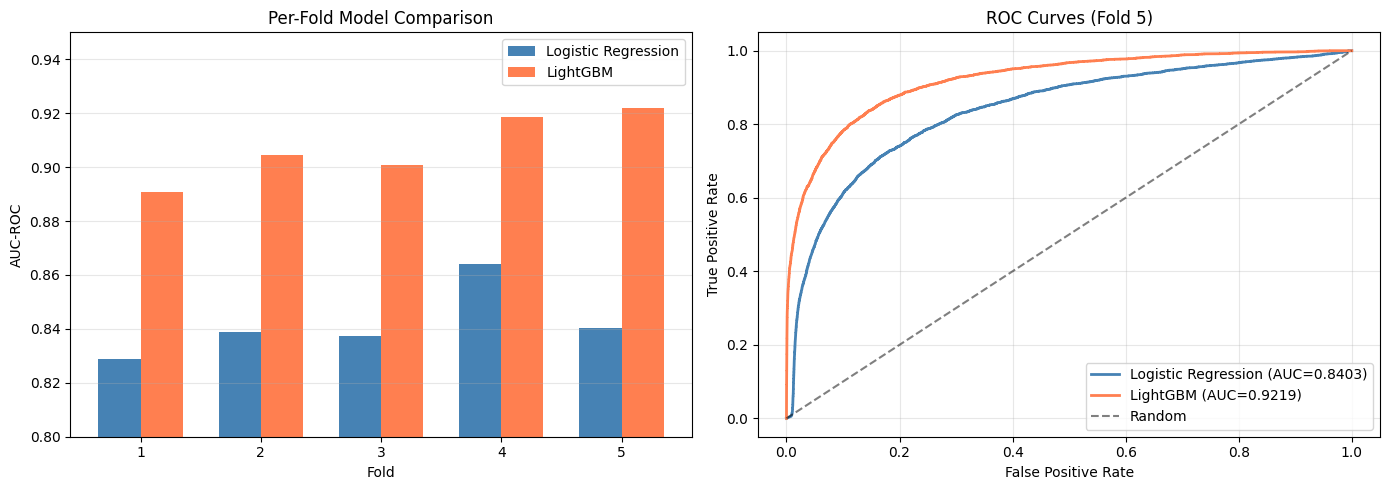

In [8]:
from sklearn.metrics import roc_curve

# Per-fold comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-fold scores
folds = range(1, 6)
width = 0.35
x = np.arange(len(folds))

axes[0].bar(x - width/2, lr_cv_scores, width, label='Logistic Regression', color='steelblue')
axes[0].bar(x + width/2, cv_scores, width, label='LightGBM', color='coral')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Per-Fold Model Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(folds)
axes[0].legend()
axes[0].set_ylim(0.8, 0.95)
axes[0].grid(True, alpha=0.3, axis='y')

# ROC curves on last fold - need to use correct datasets for each model
train_idx, val_idx = list(tscv.split(X_train_tree))[-1]

# LightGBM uses tree data
X_val_tree = X_train_tree.iloc[val_idx]
lgb_pred = models[-1].predict(X_val_tree)

# Logistic Regression uses linear data
X_val_linear = X_train_linear.iloc[val_idx]
lr_pred = lr_pipeline.predict_proba(X_val_linear)[:, 1]

y_val = y_train.iloc[val_idx]

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_val, lr_pred)
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, lgb_pred)

axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_cv_scores[-1]:.4f})', 
             linewidth=2, color='steelblue')
axes[1].plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC={cv_scores[-1]:.4f})', 
             linewidth=2, color='coral')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (Fold 5)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'model_comparison.png', dpi=150)
plt.show()

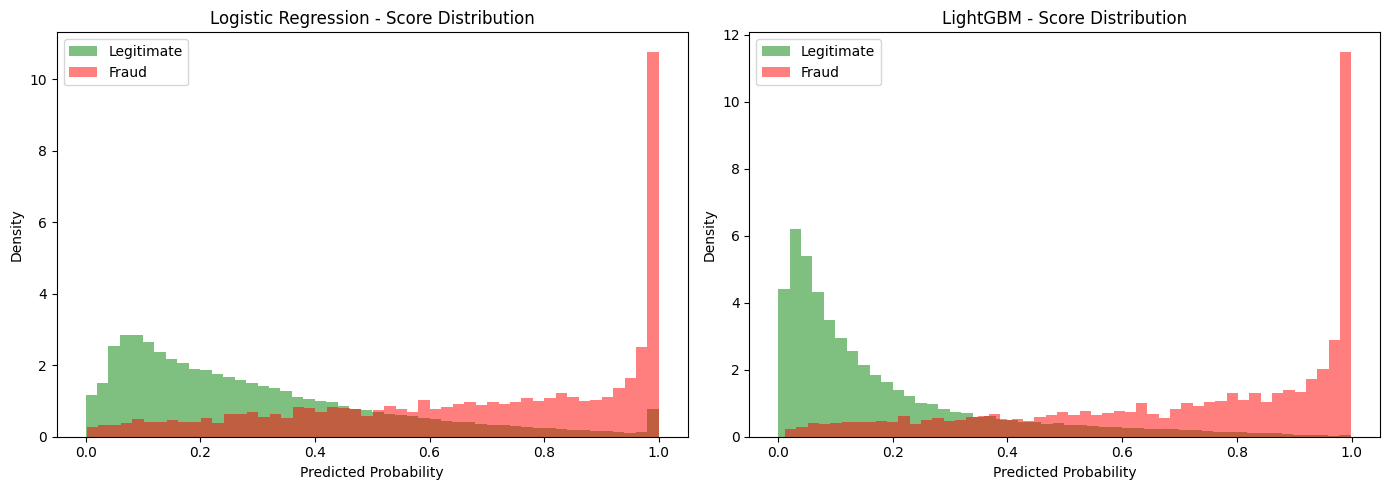

Better separation = less overlap between distributions


In [9]:
# Score distributions - how well do models separate classes?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
axes[0].hist(lr_pred[y_val == 0], bins=50, alpha=0.5, label='Legitimate', density=True, color='green')
axes[0].hist(lr_pred[y_val == 1], bins=50, alpha=0.5, label='Fraud', density=True, color='red')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Logistic Regression - Score Distribution')
axes[0].legend()

# LightGBM
axes[1].hist(lgb_pred[y_val == 0], bins=50, alpha=0.5, label='Legitimate', density=True, color='green')
axes[1].hist(lgb_pred[y_val == 1], bins=50, alpha=0.5, label='Fraud', density=True, color='red')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('LightGBM - Score Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Better separation = less overlap between distributions")

## 5. Feature Importance

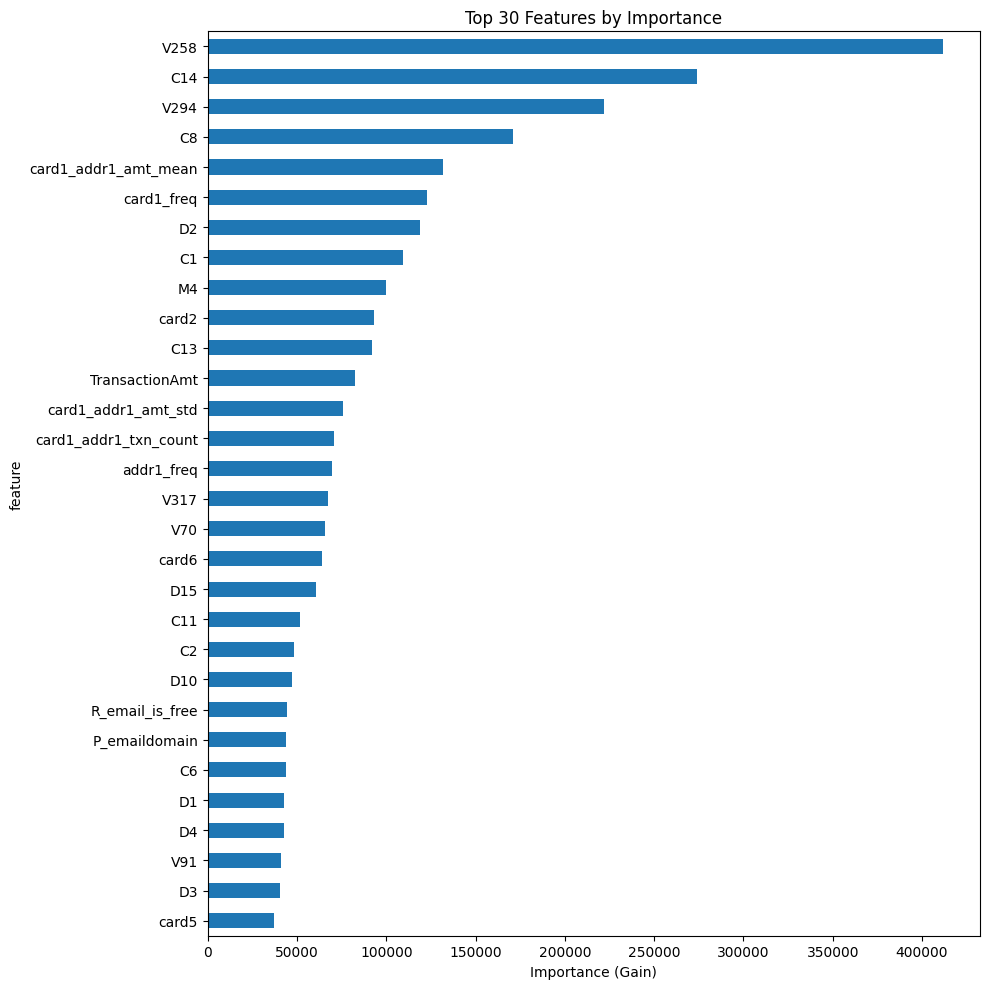

Top 20 features:
              feature    importance
                 V258 411901.847945
                  C14 274008.499549
                 V294 222145.961405
                   C8 170919.387012
 card1_addr1_amt_mean 131878.742128
           card1_freq 122512.640496
                   D2 118974.279385
                   C1 109603.703061
                   M4  99543.916244
                card2  93361.409117
                  C13  91776.130544
       TransactionAmt  82422.301155
  card1_addr1_amt_std  75623.210570
card1_addr1_txn_count  70567.127924
           addr1_freq  69393.626472
                 V317  67475.927214
                  V70  65510.792722
                card6  63877.006657
                  D15  60830.193904
                  C11  51648.135734


In [10]:
# Average feature importance across folds
importance_df = pd.DataFrame({
    'feature': X_train_tree.columns,
    'importance': np.mean([m.feature_importance(importance_type='gain') for m in models], axis=0)
}).sort_values('importance', ascending=False)

# Plot top 30
fig, ax = plt.subplots(figsize=(10, 10))
importance_df.head(30).plot(kind='barh', x='feature', y='importance', ax=ax, legend=False)
ax.set_xlabel('Importance (Gain)')
ax.set_title('Top 30 Features by Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 20 features:")
print(importance_df.head(20).to_string(index=False))

## 6. Hyperparameter Tuning (Optional)

In [11]:
# Optional: Optuna hyperparameter tuning
# Uncomment to run (takes a while)

# import optuna
# 
# def objective(trial):
#     params = {
#         'objective': 'binary',
#         'metric': 'auc',
#         'boosting_type': 'gbdt',
#         'scale_pos_weight': scale_pos_weight,
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
#         'num_leaves': trial.suggest_int('num_leaves', 20, 100),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
#         'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
#         'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
#         'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
#         'verbose': -1,
#         'random_state': 42,
#     }
#     
#     # Use last fold for quick evaluation
#     train_idx, val_idx = list(tscv.split(X_train))[-1]
#     X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
#     y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
#     
#     train_data = lgb.Dataset(X_tr, label=y_tr)
#     val_data = lgb.Dataset(X_val, label=y_val)
#     
#     model = lgb.train(params, train_data, num_boost_round=500,
#                       valid_sets=[val_data], callbacks=[lgb.early_stopping(50)])
#     
#     return roc_auc_score(y_val, model.predict(X_val))
# 
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Best AUC: {study.best_value:.4f}")
# print(f"Best params: {study.best_params}")

## 7. Train Final Model

In [12]:
# Train on full training data (using tree pipeline data)
train_data = lgb.Dataset(X_train_tree, label=y_train)

final_model = lgb.train(
    params,
    train_data,
    num_boost_round=500,  # Use fixed rounds for final model
)

print(f"Final model trained with {final_model.num_trees()} trees")

Final model trained with 500 trees


## 8. Generate Predictions

In [13]:
# Predict on test set (using tree pipeline data)
test_pred = final_model.predict(X_test_tree)

# Create submission
submission = pd.DataFrame({
    'TransactionID': test_ids,
    'isFraud': test_pred
})

submission.to_csv(DATA_DIR / 'submission.csv', index=False)
print(f"Submission saved: {submission.shape}")
print(f"\nPrediction distribution:")
print(submission['isFraud'].describe())

Submission saved: (506691, 2)

Prediction distribution:
count    506691.000000
mean          0.178834
std           0.214916
min           0.000119
25%           0.035959
50%           0.092505
75%           0.230669
max           0.999774
Name: isFraud, dtype: float64


## 9. Save Model

In [14]:
# Save model
joblib.dump(final_model, MODELS_DIR / 'lgb_model.joblib')
joblib.dump(models, MODELS_DIR / 'lgb_cv_models.joblib')

# Save CV scores
pd.DataFrame({'fold': range(1, len(cv_scores) + 1), 'auc': cv_scores}).to_csv(
    MODELS_DIR / 'cv_scores.csv', index=False
)

print(f"Models saved to {MODELS_DIR}")

Models saved to ../models
